# Spaceship Titanic Classification with ML

Bu projede, Kaggle Spaceship Titanic kapsamında verilen veri seti kullanılarak bir binary sınıflandırma problemi çözülmesi amaçlanmıştır. Amaç, uzay gemisindeki yolcuların farklı bir boyuta taşınıp taşınmadığını (Transported) tahmin eden modeller geliştirmek ve farklı makine öğrenmesi algoritmalarını karşılaştırarak en iyi performansı sağlayan modeli belirlemektir. 

In this project, a binary classification task was performed using the dataset from the Kaggle Spaceship Titanic competition. The goal was to build models that predict whether passengers were transported to another dimension, and to compare different machine learning algorithms to identify the most effective approach. 

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# Preprocessing
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [2]:
train = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')


In [3]:
print(train.shape)
print(test.shape)

(8693, 14)
(4277, 13)


In [4]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [6]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [7]:
df=pd.concat([train,test]) 

## EDA

In [8]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12682 non-null  object 
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  object 
 4   Destination   12696 non-null  object 
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  object 
 13  Transported   8693 non-null   object 
dtypes: float64(6), object(8)
memory usage: 1.5+ MB


In [10]:
df.isnull().sum()

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
Transported     4277
dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,12700.0,28.771969,14.387261,0.0,19.0,27.0,38.0,79.0
RoomService,12707.0,222.897852,647.596664,0.0,0.0,0.0,49.0,14327.0
FoodCourt,12681.0,451.961675,1584.370747,0.0,0.0,0.0,77.0,29813.0
ShoppingMall,12664.0,174.906033,590.558690,0.0,0.0,0.0,29.0,23492.0
Spa,12686.0,308.476904,1130.279641,0.0,0.0,0.0,57.0,22408.0
VRDeck,12702.0,306.789482,1180.097223,0.0,0.0,0.0,42.0,24133.0


## Data Processing & Feature Engineering

In [12]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [13]:
# Transported - Target value
df['Transported'] = df['Transported'].map({False: 1, True: 0})

In [14]:
df.CryoSleep.value_counts()

CryoSleep
False    8079
True     4581
Name: count, dtype: int64

In [15]:
df.VIP.value_counts()

VIP
False    12401
True       273
Name: count, dtype: int64

In [16]:
df['CryoSleep'] = df['CryoSleep'].map({False: 1, True: 0})
df['VIP'] = df['VIP'].map({False: 1, True: 0})

In [17]:
#Fill the Nan Values
df['CryoSleep'].fillna(df['CryoSleep'].mode()[0], inplace=True)


df['VIP'].fillna(df['VIP'].mode()[0], inplace=True)

In [18]:
# HomePlanet and Destination

df['HomePlanet'].fillna(df['HomePlanet'].mode()[0], inplace=True)

df['Destination'].fillna(df['Destination'].mode()[0], inplace=True)

In [19]:
#Age 
df['Age'].fillna(df['Age'].median(), inplace=True)

In [20]:
# Spending columns

df['RoomService'].fillna(0, inplace=True)

df['FoodCourt'].fillna(0, inplace=True)

df['ShoppingMall'].fillna(0, inplace=True)

df['Spa'].fillna(0, inplace=True)

df['VRDeck'].fillna(0, inplace=True)

In [21]:
df.isnull().sum()

PassengerId        0
HomePlanet         0
CryoSleep          0
Cabin            299
Destination        0
Age                0
VIP                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Name             294
Transported     4277
dtype: int64

In [22]:
df.Cabin.value_counts()

Cabin
G/734/S     8
G/160/P     8
B/11/S      7
G/109/P     7
C/137/S     7
           ..
F/0/P       1
F/1/S       1
B/0/P       1
E/591/P     1
F/1790/S    1
Name: count, Length: 9825, dtype: int64

In [23]:
#Cabin
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

In [24]:
print(f"- Deck: {df['Deck'].nunique()} unique")
print(f"- Num: {df['Num'].nunique()} unique")
print(f"- Side: {df['Side'].nunique()} unique")

print(f"Deck values: {df['Deck'].unique()}")
print(f"Side values: {df['Side'].unique()}")

- Deck: 8 unique
- Num: 1894 unique
- Side: 2 unique
Deck values: ['B' 'F' 'A' 'G' nan 'E' 'D' 'C' 'T']
Side values: ['P' 'S' nan]


In [25]:
df['Group'] = df['PassengerId'].str.split('_').str[0]

In [26]:
# Fill the Deck
df['Deck'] = df.groupby('Group')['Deck'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

df['Deck'] = df['Deck'].fillna('Unknown')

In [27]:
# Fill the Side
df['Side'] = df.groupby('Group')['Side'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

df['Side'] = df['Side'].fillna(df['Side'].mode()[0])

In [28]:
#Fill the Num (the same deck similar cabin num )

#Convert to numeric
df['Num'] = pd.to_numeric(df['Num'], errors='coerce')

#Fill with Group + Deck
df['Num'] = df.groupby(['Group','Deck'])['Num'].transform(
    lambda x: x.fillna(x.median())
)

#Fill in the rest with the median
df['Num'] = df['Num'].fillna(df['Num'].median())

In [29]:
df.isnull().sum()

PassengerId        0
HomePlanet         0
CryoSleep          0
Cabin            299
Destination        0
Age                0
VIP                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Name             294
Transported     4277
Deck               0
Num                0
Side               0
Group              0
dtype: int64

In [30]:
# Drop
df = df.drop(columns=['Cabin','Name'])

In [31]:
df.isnull().sum()

PassengerId        0
HomePlanet         0
CryoSleep          0
Destination        0
Age                0
VIP                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Transported     4277
Deck               0
Num                0
Side               0
Group              0
dtype: int64

In [32]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Num,Side,Group
0,0001_01,Europa,1.0,TRAPPIST-1e,39.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,B,0.0,P,0001
1,0002_01,Earth,1.0,TRAPPIST-1e,24.0,1.0,109.0,9.0,25.0,549.0,44.0,0.0,F,0.0,S,0002
2,0003_01,Europa,1.0,TRAPPIST-1e,58.0,0.0,43.0,3576.0,0.0,6715.0,49.0,1.0,A,0.0,S,0003
3,0003_02,Europa,1.0,TRAPPIST-1e,33.0,1.0,0.0,1283.0,371.0,3329.0,193.0,1.0,A,0.0,S,0003
4,0004_01,Earth,1.0,TRAPPIST-1e,16.0,1.0,303.0,70.0,151.0,565.0,2.0,0.0,F,1.0,S,0004


In [33]:
abs(df.corr(numeric_only=True))['Transported'].sort_values(ascending=False)

Transported     1.000000
CryoSleep       0.460132
RoomService     0.241124
Spa             0.218545
VRDeck          0.204874
Age             0.074233
Num             0.046059
FoodCourt       0.045583
VIP             0.037261
ShoppingMall    0.009391
Name: Transported, dtype: float64

In [34]:
df['Total_Spending'] = df['RoomService'] + df['FoodCourt'] + df['ShoppingMall'] + df['Spa'] + df['VRDeck']
df['Is_Spender'] = (df['Total_Spending'] > 0).astype(int)

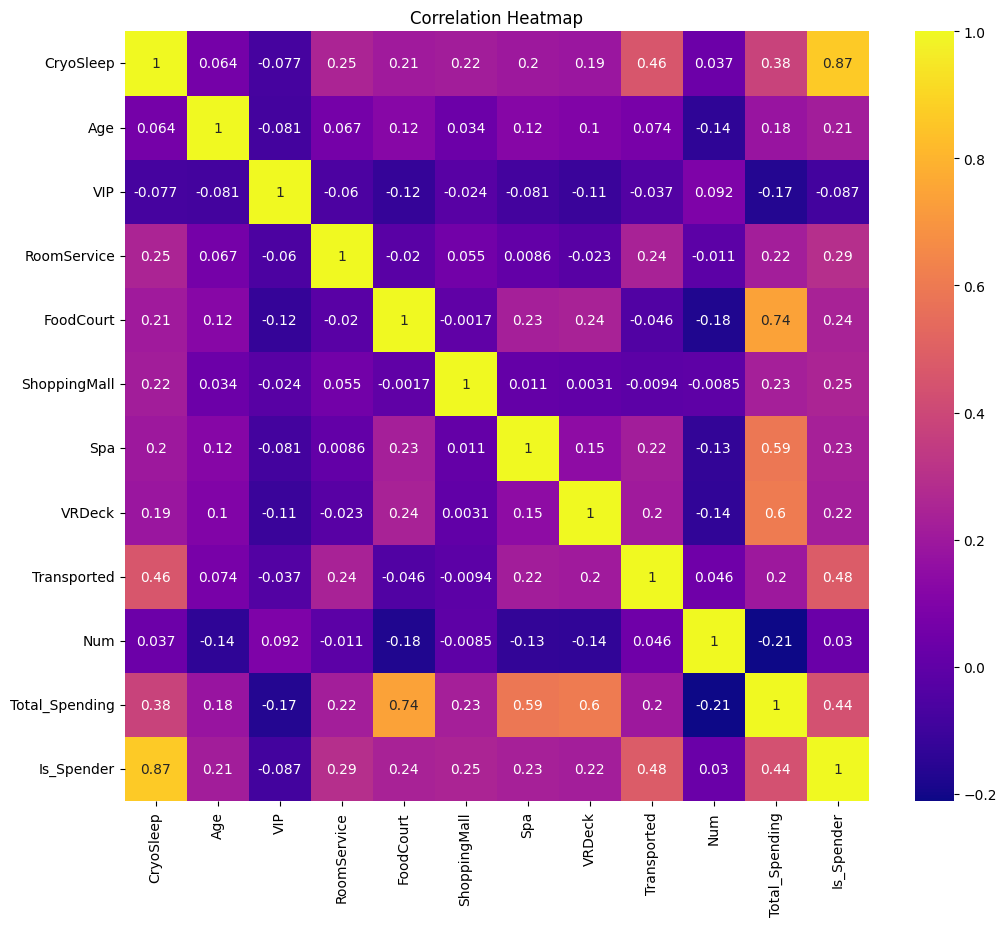

In [35]:
#Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='plasma')
plt.title('Correlation Heatmap')
plt.show()

In [36]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Num,Side,Group,Total_Spending,Is_Spender
0,0001_01,Europa,1.0,TRAPPIST-1e,39.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,B,0.0,P,0001,0.0,0
1,0002_01,Earth,1.0,TRAPPIST-1e,24.0,1.0,109.0,9.0,25.0,549.0,44.0,0.0,F,0.0,S,0002,736.0,1
2,0003_01,Europa,1.0,TRAPPIST-1e,58.0,0.0,43.0,3576.0,0.0,6715.0,49.0,1.0,A,0.0,S,0003,10383.0,1
3,0003_02,Europa,1.0,TRAPPIST-1e,33.0,1.0,0.0,1283.0,371.0,3329.0,193.0,1.0,A,0.0,S,0003,5176.0,1
4,0004_01,Earth,1.0,TRAPPIST-1e,16.0,1.0,303.0,70.0,151.0,565.0,2.0,0.0,F,1.0,S,0004,1091.0,1


## Model Training

In [37]:
train = df[df['Transported'].notna()]
test  = df[df['Transported'].isna()]

In [38]:
x = train.drop(['PassengerId', 'Transported','Group'], axis=1)
y = train['Transported']

In [39]:
x_final_test = test.drop(['PassengerId','Transported','Group'], axis=1)

In [40]:
x_all = pd.concat([x, x_final_test])
x_all = pd.get_dummies(x_all, drop_first=True)

In [41]:
x = x_all.iloc[:len(x)]
x_final_test = x_all.iloc[len(x):]

In [42]:
def algo_test(x, y):
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=500, solver='lbfgs'),   
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        MultinomialNB(),
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42),
        LGBMClassifier(verbose=-1, random_state=42),
        CatBoostClassifier(verbose=0, random_state=42)
    ]
    isimler = [
        "BernoulliNB", 
        "LogisticRegression", 
        "DecisionTreeClassifier", 
        "RandomForestClassifier", 
        "GradientBoostingClassifier", 
        "KNeighborsClassifier", 
        "AdaBoostClassifier", 
        "MultinomialNB",
        "XGBClassifier",
        "LGBMClassifier",
        "CatBoostClassifier"
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    accuracy, precision, recall, f1, mdl = [], [], [], [], []
    
    print("Veriler hazır, modeller deneniyor...")
    for name, model in zip(isimler, modeller):
        print(f"{name} modeli eğitiliyor...")
        if isinstance(model, MultinomialNB):
            if (np.array(x_train) < 0).any():
                print("Uyarı: MultinomialNB negatif değerlerle çalışmaz, bu model atlanıyor!")
                accuracy.append(np.nan)
                precision.append(np.nan)
                recall.append(np.nan)
                f1.append(np.nan)
                mdl.append(None)
                continue
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="binary"))
            recall.append(recall_score(y_test, tahmin, average="binary"))
            f1.append(f1_score(y_test, tahmin, average="binary"))
            print(confusion_matrix(y_test, tahmin))
        except Exception as e:
            print(f"{name} modeli çalıştırılırken hata oluştu: {e}")
            accuracy.append(np.nan)
            precision.append(np.nan)
            recall.append(np.nan)
            f1.append(np.nan)
            mdl.append(None)
    
    print("Eğitim tamamlandı.")
    
    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Model": mdl
    }, index=isimler)

    metrics_sorted = metrics.sort_values("F1", ascending=False)
    
    print("\n" + "="*80)
    print("En başarılı model:", metrics_sorted.dropna().iloc[0].name)
    print("="*80)
    
    en_iyi_model = metrics_sorted.dropna().iloc[0]["Model"]

    tahmin = en_iyi_model.predict(x_test)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("\nClassification Report:")
    print(classification_report(y_test, tahmin))

    print("\n" + "="*80)
    print("TÜM MODELLERİN KARŞILAŞTIRMASI")
    print("="*80)
    print(metrics_sorted.drop("Model", axis=1))

    return metrics_sorted.drop("Model", axis=1)

In [43]:
algo_test(x,y)

Veriler hazır, modeller deneniyor...
BernoulliNB modeli eğitiliyor...
[[591 287]
 [164 697]]
LogisticRegression modeli eğitiliyor...
[[721 157]
 [220 641]]
DecisionTreeClassifier modeli eğitiliyor...
[[665 213]
 [234 627]]
RandomForestClassifier modeli eğitiliyor...
[[680 198]
 [161 700]]
GradientBoostingClassifier modeli eğitiliyor...
[[735 143]
 [211 650]]
KNeighborsClassifier modeli eğitiliyor...
[[688 190]
 [237 624]]
AdaBoostClassifier modeli eğitiliyor...
[[689 189]
 [208 653]]
MultinomialNB modeli eğitiliyor...
[[798  80]
 [349 512]]
XGBClassifier modeli eğitiliyor...
[[700 178]
 [181 680]]
LGBMClassifier modeli eğitiliyor...
[[722 156]
 [175 686]]
CatBoostClassifier modeli eğitiliyor...
[[723 155]
 [183 678]]
Eğitim tamamlandı.

En başarılı model: LGBMClassifier

Confusion Matrix:
[[722 156]
 [175 686]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81       878
         1.0       0.81      0.80      0.81 

,Accuracy,Precision,Recall,F1
LGBMClassifier,0.809661,0.814727,0.796748,0.805637
CatBoostClassifier,0.805635,0.813926,0.787456,0.800472
RandomForestClassifier,0.793560,0.779510,0.813008,0.795907
XGBClassifier,0.793560,0.792541,0.789779,0.791158
GradientBoostingClassifier,0.796435,0.819672,0.754936,0.785973
LogisticRegression,0.783209,0.803258,0.744483,0.772755
AdaBoostClassifier,0.771708,0.775534,0.758420,0.766882
BernoulliNB,0.740656,0.708333,0.809524,0.755556
KNeighborsClassifier,0.754457,0.766585,0.724739,0.745075
DecisionTreeClassifier,0.742956,0.746429,0.728223,0.737213


In [44]:
best_model= LGBMClassifier(verbose=-1, random_state=42)
best_model.fit(x,y)

LGBMClassifier(random_state=42, verbose=-1)

In [45]:
prediction= best_model.predict(x_final_test)

In [46]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': prediction
})

In [47]:
submission.head()

,PassengerId,Transported
0,0013_01,0.0
1,0018_01,1.0
2,0019_01,0.0
3,0021_01,0.0
4,0023_01,0.0


In [48]:
submission['Transported'] = submission['Transported'].map({1.0: 'False', 0.0: 'True'})

In [49]:
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [50]:
submission.to_csv("submission.csv", index=False)

Elde edilen sonuçlara göre LGBMClassifier yaklaşık %80.97 doğruluk ile en başarılı model olmuştur. CatBoost ve diğer boosting tabanlı modeller de benzer şekilde yüksek performans göstermiştir. RandomForest ve XGBoost modelleri orta seviyede sonuçlar üretirken, Logistic Regression ve Naive Bayes gibi daha basit modeller daha düşük performans sergilemiştir. Genel olarak boosting tabanlı algoritmaların bu veri setinde daha güçlü sonuçlar verdiği ve yaklaşık %80 civarındaki doğruluk değerlerinin bu yarışma için makul bir performans seviyesi olduğu gözlemlenmiştir .

According to the results, LGBMClassifier achieved the best performance with approximately 80.97% accuracy. CatBoost and other boosting-based models also delivered strong results. RandomForest and XGBoost showed moderate performance, while simpler models such as Logistic Regression and Naive Bayes performed relatively worse. Overall, boosting algorithms proved to be the most effective, and achieving around 80% accuracy is considered a solid performance level for this competition 